In [1]:
import numpy as np
import pandas as pd
import scipy.stats as ss
from operator import attrgetter

import seaborn as sns
import plotly.express as px
import matplotlib.pyplot as plt
from matplotlib import colors as mcolors

In [2]:
#Cчитываем таблицу с уникальными идентификаторами пользователей и смотрим на её содержимое

olist_customers_dataset = pd.read_csv('olist_customers_dataset.csv')
olist_customers_dataset.head()

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
0,06b8999e2fba1a1fbc88172c00ba8bc7,861eff4711a542e4b93843c6dd7febb0,14409,franca,SP
1,18955e83d337fd6b2def6b18a428ac77,290c77bc529b7ac935b93aa66c333dc3,9790,sao bernardo do campo,SP
2,4e7b3e00288586ebd08712fdd0374a03,060e732b5b29e8181a18229c7b0b2b5e,1151,sao paulo,SP
3,b2b6027bc5c5109e529d4dc6358b12c3,259dac757896d24d7702b9acbbff3f3c,8775,mogi das cruzes,SP
4,4f2d8ab171c80ec8364f7c12e35b23ad,345ecd01c38d18a9036ed96c73b8d066,13056,campinas,SP


In [3]:
#Смотрим на её размер

olist_customers_dataset.shape

(99441, 5)

In [4]:
#Проверяем таблицу на наличие NA значений

olist_customers_dataset.isna().sum()

customer_id                 0
customer_unique_id          0
customer_zip_code_prefix    0
customer_city               0
customer_state              0
dtype: int64

In [5]:
#Смотрим на типы данных в разных столбцах

olist_customers_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 5 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   customer_id               99441 non-null  object
 1   customer_unique_id        99441 non-null  object
 2   customer_zip_code_prefix  99441 non-null  int64 
 3   customer_city             99441 non-null  object
 4   customer_state            99441 non-null  object
dtypes: int64(1), object(4)
memory usage: 3.8+ MB


In [6]:
#Смотрим на кол-во уникальных значений в каждом столбце

olist_customers_dataset.nunique()

customer_id                 99441
customer_unique_id          96096
customer_zip_code_prefix    14994
customer_city                4119
customer_state                 27
dtype: int64

In [7]:
#Cчитываем таблицу заказов и смотрим на её содержимое

olist_orders_dataset = pd.read_csv('olist_orders_dataset.csv')
olist_orders_dataset.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [8]:
#Смотрим на её размер

olist_orders_dataset.shape

(99441, 8)

In [9]:
#Проверяем таблицу на наличие NA значений

olist_orders_dataset.isna().sum()

order_id                            0
customer_id                         0
order_status                        0
order_purchase_timestamp            0
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
order_estimated_delivery_date       0
dtype: int64

In [10]:
#Смотрим на кол-во уникальных значений в каждом столбце

olist_orders_dataset.nunique()

order_id                         99441
customer_id                      99441
order_status                         8
order_purchase_timestamp         98875
order_approved_at                90733
order_delivered_carrier_date     81018
order_delivered_customer_date    95664
order_estimated_delivery_date      459
dtype: int64

In [11]:
#Смотрим на типы данных в разных столбцах

olist_orders_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [12]:
#Переводим все временные серии в формат дата:время

olist_orders_dataset.order_purchase_timestamp = pd.to_datetime(olist_orders_dataset.order_purchase_timestamp)
olist_orders_dataset.order_approved_at = pd.to_datetime(olist_orders_dataset.order_approved_at)
olist_orders_dataset.order_delivered_carrier_date = pd.to_datetime(olist_orders_dataset.order_delivered_carrier_date)
olist_orders_dataset.order_delivered_customer_date = pd.to_datetime(olist_orders_dataset.order_delivered_customer_date)
olist_orders_dataset.order_estimated_delivery_date = pd.to_datetime(olist_orders_dataset.order_estimated_delivery_date)

In [13]:
#Cчитываем таблицу товарных позиций, входящих в заказы, и смотрим на её содержимое

olist_order_items_dataset = pd.read_csv('olist_order_items_dataset.csv')
olist_order_items_dataset.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [14]:
#Смотрим на её размер

olist_order_items_dataset.shape

(112650, 7)

In [15]:
#Проверяем таблицу на наличие NA значений

olist_order_items_dataset.isna().sum()

order_id               0
order_item_id          0
product_id             0
seller_id              0
shipping_limit_date    0
price                  0
freight_value          0
dtype: int64

In [16]:
#Смотрим на кол-во уникальных значений в каждом столбце

olist_order_items_dataset.nunique()

order_id               98666
order_item_id             21
product_id             32951
seller_id               3095
shipping_limit_date    93318
price                   5968
freight_value           6999
dtype: int64

In [17]:
#Смотрим на типы данных в разных столбцах

olist_order_items_dataset.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [18]:
#Переводим все временные серии в формат дата:время

olist_order_items_dataset.shipping_limit_date = pd.to_datetime(olist_order_items_dataset.shipping_limit_date)

In [19]:
#Смотрим на структуру данных на примере конкретного заказа

olist_order_items_dataset.query('order_id == "00143d0f86d6fbd9f9b38ab440ac16f5"')

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
32,00143d0f86d6fbd9f9b38ab440ac16f5,1,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.1
33,00143d0f86d6fbd9f9b38ab440ac16f5,2,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.1
34,00143d0f86d6fbd9f9b38ab440ac16f5,3,e95ee6822b66ac6058e2e4aff656071a,a17f621c590ea0fab3d5d883e1630ec6,2017-10-20 16:07:52,21.33,15.1


In [20]:
olist_orders_dataset.query('order_id == "00143d0f86d6fbd9f9b38ab440ac16f5"')

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
36265,00143d0f86d6fbd9f9b38ab440ac16f5,2e45292979b9b2700ea09560eeb0f803,delivered,2017-10-16 15:29:43,2017-10-16 16:07:52,2017-10-16 23:04:43,2017-10-27 18:43:56,2017-11-06


In [21]:
olist_customers_dataset.query('customer_id == "2e45292979b9b2700ea09560eeb0f803"')

,customer_id,customer_unique_id,customer_zip_code_prefix,customer_city,customer_state
58260,2e45292979b9b2700ea09560eeb0f803,bb8a37225e0279ac8a274c9765617eaf,74663,goiania,GO


In [ ]:
# Оценим месячный retention в оформление заказа с помощью когортного анализа.
# Для того, чтобы определить, какой вид заказа будет учитываться в retention, мы исследуем таблицу заказов, сгруппировав данные по статусу заказа и посмотрим на их объём

orders_list_by_status = olist_orders_dataset.groupby('order_status').agg({'order_id': 'count'})
orders_list_by_status

,order_id
order_status,
approved,2
canceled,625
created,5
delivered,96478
invoiced,314
processing,301
shipped,1107
unavailable,609


In [23]:
# Как видно выше, наибольшая доля заказов (97%) доставлена, а записи о заказах удаляются из предыдущих стадий после перехода в новые.
# Так что построим месячный retention на основании доставленных заказов (status == 'delivered').
# Для этого:

# 1) Создаем новый датасет, в котором отберём только доставленные заказы

olist_orders_dataset_copy = olist_orders_dataset.query('order_status == "delivered"')

In [24]:
# 2) Извлекаем месяц и день заказа

olist_orders_dataset_copy['order_period'] = olist_orders_dataset_copy['order_purchase_timestamp'].dt.to_period('M')
olist_orders_dataset_copy['order_period_day'] = olist_orders_dataset_copy['order_purchase_timestamp'].dt.to_period('D')

/opt/tljh/user/lib/python3.7/site-packages/ipykernel_launcher.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  This is separate from the ipykernel package so we can avoid doing imports until
/opt/tljh/user/lib/python3.7/site-packages/ipykernel_launcher.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  after removing the cwd from sys.path.


In [25]:
# 2) Примёрдживаем уникальные id клиентов из таблицы с уникальными идентификаторами пользователей

olist_orders_dataset_copy = olist_orders_dataset_copy.merge(olist_customers_dataset[['customer_id', 'customer_unique_id']], how='inner', on='customer_id')

In [26]:
# 3) Присваиваем когорты на основе даты первого действия для каждого пользователя (по уникальному id)

olist_orders_dataset_copy['cohort'] = olist_orders_dataset_copy.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('M')
olist_orders_dataset_copy['cohort_day'] = olist_orders_dataset_copy.groupby('customer_unique_id')['order_purchase_timestamp'].transform('min').dt.to_period('D')

In [27]:
# 4) Рассчитываем номер периода в днях (месячные периоды, деля на 30)

olist_orders_dataset_copy['period_number_month'] = np.floor((olist_orders_dataset_copy.order_period_day - olist_orders_dataset_copy.cohort_day).apply(attrgetter('n')) / 30)

In [28]:
olist_orders_dataset_copy.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_period,order_period_day,customer_unique_id,cohort,cohort_day,period_number_month
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,2017-10,2017-10-02,7c396fd4830fd04220f754e42b4e5bff,2017-09,2017-09-04,0.0
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,2018-07,2018-07-24,af07308b275d755c9edb36a90c618231,2018-07,2018-07-24,0.0
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,2018-08,2018-08-08,3a653a41f6f9fc3d2a113cf8398680e8,2018-08,2018-08-08,0.0
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,2017-11,2017-11-18,7c142cf63193a1473d2e66489a9ae977,2017-11,2017-11-18,0.0
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,2018-02,2018-02-13,72632f0f9dd73dfee390c9b22eb56dd6,2018-02,2018-02-13,0.0


In [29]:
# 5) Агрегируем данные по когортам и рассчитанному номеру периода (в месяцах)

df_cohort = olist_orders_dataset_copy.groupby(['cohort', 'period_number_month']).agg(n_customers=('customer_unique_id', 'nunique')).reset_index()
df_cohort.head()

,cohort,period_number_month,n_customers
0,2016-09,0.0,1
1,2016-10,0.0,262
2,2016-10,6.0,1
3,2016-10,9.0,1
4,2016-10,11.0,1


In [30]:
# 6) Создаем сводную таблицу для когортного анализа

cohort_pivot = df_cohort.pivot_table(index='cohort', columns='period_number_month', values='n_customers')
cohort_pivot.head()

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,262.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,1.0,...,1.0,NaN,1.0,NaN,1.0,NaN,1.0,2.0,1.0,1.0
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,717.0,2.0,NaN,4.0,1.0,1.0,2.0,2.0,NaN,NaN,...,4.0,3.0,2.0,NaN,2.0,2.0,2.0,1.0,NaN,NaN
2017-02,1628.0,2.0,3.0,6.0,4.0,2.0,4.0,1.0,2.0,4.0,...,6.0,1.0,3.0,2.0,1.0,1.0,3.0,NaN,NaN,NaN


In [31]:
# 7) Рассчитываем размеры когорт (первый столбец сводной таблицы)

cohort_size = cohort_pivot.iloc[:, 0]

In [32]:
# Вычисляем коэффициенты удержания, деля на размер когорты
retention_matrix = cohort_pivot.divide(cohort_size, axis=0)
retention_matrix.head()

period_number_month,0.0,1.0,2.0,3.0,4.0,5.0,6.0,7.0,8.0,9.0,...,11.0,12.0,13.0,14.0,15.0,16.0,17.0,19.0,20.0,21.0
cohort,,,,,,,,,,,,,,,,,,,,,
2016-09,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2016-10,1.0,NaN,NaN,NaN,NaN,NaN,0.003817,NaN,NaN,0.003817,...,0.003817,NaN,0.003817,NaN,0.003817,NaN,0.003817,0.007634,0.003817,0.003817
2016-12,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
2017-01,1.0,0.002789,NaN,0.005579,0.001395,0.001395,0.002789,0.002789,NaN,NaN,...,0.005579,0.004184,0.002789,NaN,0.002789,0.002789,0.002789,0.001395,NaN,NaN
2017-02,1.0,0.001229,0.001843,0.003686,0.002457,0.001229,0.002457,0.000614,0.001229,0.002457,...,0.003686,0.000614,0.001843,0.001229,0.000614,0.000614,0.001843,NaN,NaN,NaN


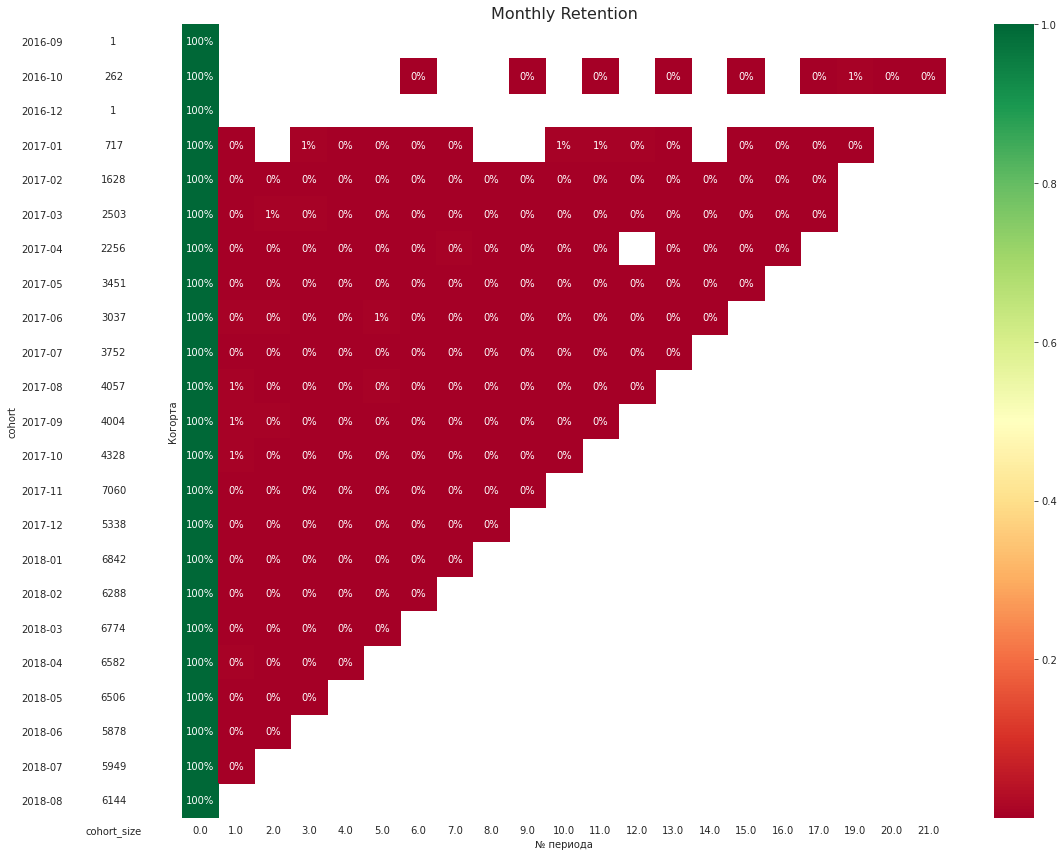

In [33]:
# Строим тепловую карту когортного анализа
with sns.axes_style("white"):
    fig, ax = plt.subplots(1, 2, figsize=(16, 12), sharey=True, gridspec_kw={'width_ratios': [1, 11]})

    # Тепловая карта для коэффициентов удержания
    sns.heatmap(retention_matrix,
                mask=retention_matrix.isnull(),
                annot=True,
                fmt='.0%',
                cmap='RdYlGn',
                ax=ax[1])
    ax[1].set_title('Monthly Retention', fontsize=16)
    ax[1].set(xlabel='№ периода', ylabel='Когорта')

    # Тепловая карта для размеров когорт
    cohort_size_df = pd.DataFrame(cohort_size).rename(columns={0: 'cohort_size'})
    white_cmap = mcolors.ListedColormap(['white'])
    sns.heatmap(cohort_size_df,
                annot=True,
                cbar=False,
                fmt='g',
                cmap=white_cmap,
                ax=ax[0])

    fig.tight_layout()
    plt.show()

In [34]:
# Смотрим, чему равен медианный retention 1-го месяца

retention_matrix[1].median()

0.0035460992907801418

In [35]:
# Находим когорту с самым высоким retention на 3-й месяц

retention_matrix.loc[:, 3].idxmax()

Period('2017-01', 'M')

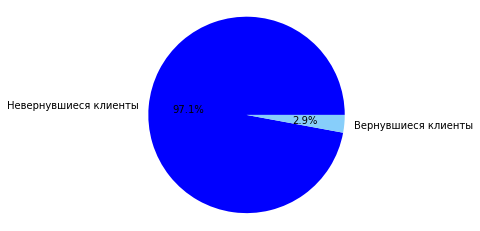

In [36]:
# Как видно из тепловой карты выше, у нас очень низкий процент клиентов, совершающих повторные покупки.
# При стандартном пороговом значении retention в 30% значения нашего показателя не превосходят 1%. Это говорит о том, что PMF не достигнут.
# Пользователи приходят, пробуют — и не возвращаются. Это значит, что маркетплейс не решает их проблему настолько, чтобы они захотели вернуться.
# Доля клиентов, кто совершил более 1 заказа, составляет всего 2,9%

return_share = round(olist_orders_dataset_copy.groupby('customer_unique_id')\
                         .agg({'order_id': 'nunique'})\
                         .query('order_id > 1').shape[0] / olist_orders_dataset_copy.shape[0] * 100, 2)

# Данные для диаграммы  
labels = ['Невернувшиеся клиенты', 'Вернувшиеся клиенты']  
sizes = [(100 - return_share), return_share] 
colors = ['blue', 'lightskyblue']
plt.pie(sizes, labels=labels, colors=colors, autopct='%1.1f%%')   
plt.axis('equal')  
plt.show() 

In [37]:
# Причинами этого могут быть:
    #1) Низкое качество ассортимента - наш покупатель не находит то, что ищет. 
    #2) Плохой пользовательский опыт - сложный процесс заказа, сайт/приложение неудобны.
    #3) Неудовлетворённость доставкой - долго, дорого или срыв сроков.
    #4) Невысокое доверие к платформе - продавцы медленно обрабатывают заказы, плохие описания товаров или фото

In [38]:
# Определим 5 основных метрик, на которых можно сконцентрироваться, чтобы максимизировать прибыль компании:
    #1) Объем завершённых заказов
    #2) Количество уникальных активных покупателей
    #3) Конверсия новых пользователей в первый заказ
    #4) Retention Rate
    #5) Средняя выручка на одного пользователя (ARPU)
    
# Их текущие значения составляют:

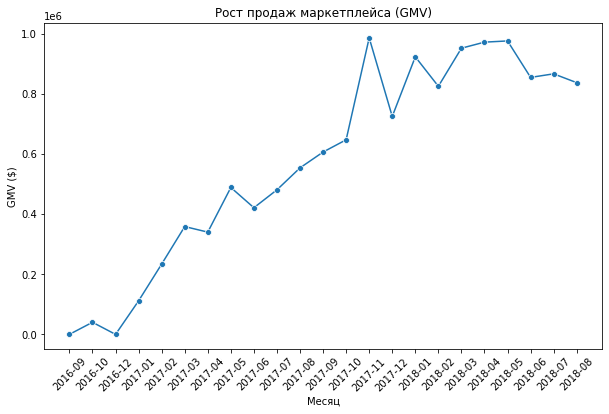

In [39]:
#1) Объем завершённых заказов

gmv_data = olist_orders_dataset_copy.merge(olist_order_items_dataset[['order_id', 'price']], on='order_id')
monthly_gmv = gmv_data.groupby('order_period')['price'].sum().reset_index()
monthly_gmv['order_period'] = monthly_gmv['order_period'].astype(str)
monthly_gmv.columns = ['order_period', 'GMV']

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_gmv, x='order_period', y='GMV', marker='o')
plt.title('Рост продаж маркетплейса (GMV)')
plt.xlabel('Месяц')
plt.ylabel('GMV ($)')
plt.xticks(rotation=45)

plt.show()

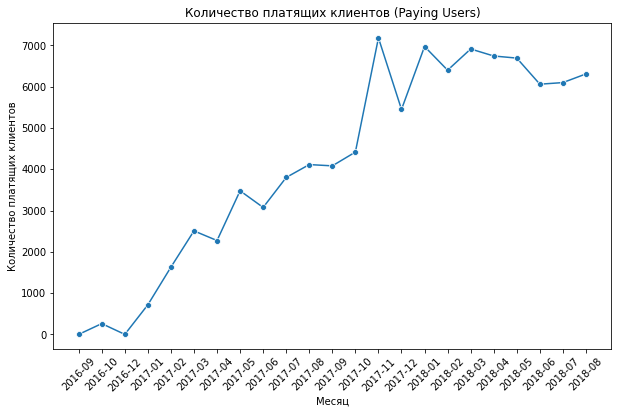

In [40]:
#2) Количество уникальных активных покупателей

paying_users = olist_orders_dataset_copy.groupby(olist_orders_dataset_copy['order_period']).customer_unique_id.nunique().reset_index()
paying_users['order_period'] = paying_users['order_period'].astype(str)
paying_users.columns = ['order_period', 'paying_users']

plt.figure(figsize=(10, 6))
sns.lineplot(data=paying_users, x='order_period', y='paying_users', marker='o')
plt.title('Количество платящих клиентов (Paying Users)')
plt.xlabel('Месяц')
plt.ylabel('Количество платящих клиентов')
plt.xticks(rotation=45)

plt.show()

Text(0, 0.5, 'Retention rate')

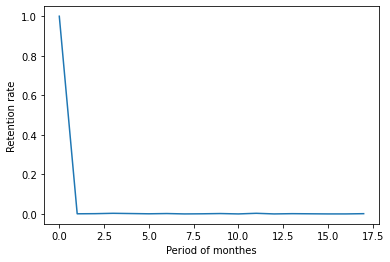

In [41]:
#4) Retention Rate

#продемонстрируем Retention Rate по когорте от февраля 2017-го года:

retention_matrix.loc[retention_matrix.index == '2017-02'].iloc[0].plot()
plt.xlabel('Period of monthes')
plt.ylabel('Retention rate')

In [42]:
#5) Средняя выручка на одного пользователя (ARPU)

order_all_info = gmv_data.merge(olist_customers_dataset[['customer_id', 'customer_unique_id']], on='customer_id')

monthly_revenue = order_all_info.groupby('order_period').agg(
    total_revenue=('price', 'sum'),
    paying_users=('customer_unique_id_y', 'nunique')).reset_index()

monthly_revenue['ARRPU'] = monthly_revenue['total_revenue'] / monthly_revenue['paying_users']

monthly_revenue[['order_period', 'total_revenue', 'paying_users', 'ARRPU']]

,order_period,total_revenue,paying_users,ARRPU
0,2016-09,134.97,1,134.970000
1,2016-10,40325.11,262,153.912634
2,2016-12,10.90,1,10.900000
3,2017-01,111798.36,718,155.708022
4,2017-02,234223.40,1630,143.695337
5,2017-03,359198.85,2508,143.221232
6,2017-04,340669.68,2274,149.810765
7,2017-05,489338.25,3479,140.654858
8,2017-06,421923.37,3076,137.166245
9,2017-07,481604.52,3802,126.671362


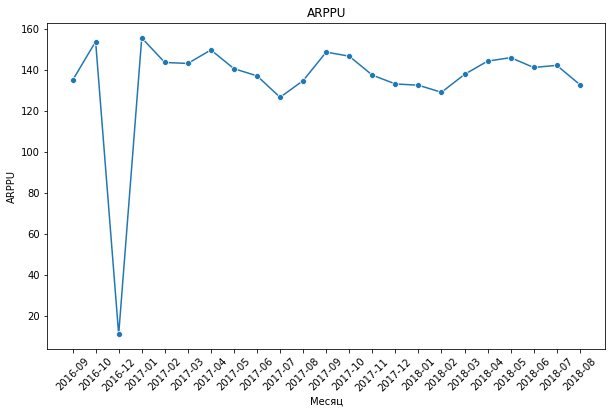

In [43]:
monthly_revenue['order_period'] = monthly_revenue['order_period'].astype(str)

plt.figure(figsize=(10, 6))
sns.lineplot(data=monthly_revenue, x='order_period', y='ARRPU', marker='o')
plt.title('ARPPU')
plt.xlabel('Месяц')
plt.ylabel('ARPPU')
plt.xticks(rotation=45)

plt.show()

In [ ]:
# Выберем одну из 3 основных гипотез с помощью фреймворка ICE.

In [45]:
# Гипотеза №1. Если исправим баг в системе процессинга заказов, то клиентам не придётся сталкиваться с проблемой отмены заказа, 
# вследствие чего количество доставленных заказов увеличится. Считаем, что мы таким образом избавимся от всех отмен.

# Для того чтобы определить impact данной гепотезы, давайте рассчитаем кол-во отменённых заказов (canceled + unavailable)

count_canceled = olist_orders_dataset[(olist_orders_dataset.order_purchase_timestamp >= '2017-06') &
                        (olist_orders_dataset.order_status.isin(['canceled', 'unavailable']))].order_id.nunique()
print(f'Количество отмененных заказов: {count_canceled}')

Количество отмененных заказов: 974


In [46]:
# Гипотеза #2. Если сократим время до отгрузки заказа, то клиенты перестанут получать свой заказ с запаздыванием, 
# вследствие чего количество заказов увеличится за счет повторных заказов.

# Для того чтобы определить impact данной гепотезы, давайте рассчитаем кол-во заказов с задержкой доставки (delivery_day > order_estimated_day). 
# Конверсию в повторный заказ возьмем равной 0.0035.

count_delayed = olist_orders_dataset[(olist_orders_dataset.order_purchase_timestamp >= '2017-06') & (olist_orders_dataset.order_delivered_customer_date > olist_orders_dataset.order_estimated_delivery_date)
                      & (olist_orders_dataset.order_status.isin(['delivered']))].order_id.nunique()

In [47]:
print(f'Количество задержанных заказов: {count_delayed}')

Количество задержанных заказов: 7295


In [48]:
print(f'Возможное количество повторных заказов: {count_delayed*0.0035}')

Возможное количество повторных заказов: 25.5325


In [49]:
# Гипотеза №3. Если создадим новый способ оплаты, который будет конвертировать клиентов в повторный заказ, то клиенты не будут испытывать трудности при выполнении заказа, 
# вследствие чего количество заказов увеличится за счет повторных заказов.

# Для того чтобы определить impact данной гепотезы, давайте рассчитаем кол-во единичных заказов. 
# Конверсию в повторный заказ возьмем равной 0.0035.

# 1) отбираем заказы после июня 2017го
# 2) группируем по уникальному id покупателей
# 3) подсчитываем кол-во заказов по каждому уникальному id покупателей
# 4) отбираем только тех покупателей, у которых 1 заказ
# 5) подсчитываем кол-во таких покупателей

customer_order_counts = olist_orders_dataset_copy[(olist_orders_dataset_copy.order_period >= '2017-06')]\
.groupby('customer_unique_id')\
.order_id.nunique().reset_index()\
.query('order_id == 1')\
.order_id.sum()

print(f'Количество покупателей, сделавших только один заказ: {customer_order_counts}')

Количество покупателей, сделавших только один заказ: 80558


In [50]:
print(f'Возможное количество повторных заказов: {customer_order_counts*0.0035}')

Возможное количество повторных заказов: 281.95300000000003


In [51]:
# Итого по фреймворку ICE гипотезы имеют следующий рейтинг:
# Гипотеза №1 - 8 * 8 * 6 = 384
# Гипотеза №2 - 1 * 10 * 4 = 40
# Гипотеза №3 - 3 * 5 * 9 = 135
# Соответственно начать необходимо с проверки оменно 1-й гипотезы.

In [ ]:
# Сформулируем нужные метрики, на которые наша гипотеза должна повлиять.

In [53]:
# Целевой метрикой при проверке гепотезы №1 будет "Количество доставленных заказов". 
# Не будет бага = не будет отмены заказов = больше заказов будет доставлено.
# После запуска А/В-теста нужно будет проверить, увеличилось ли кол-во доставленных заказов у тестовой группы.

In [54]:
# Прокси метрикой при проверке гепотезы №1 будет "Конверсия в доставку товара до покупателя". 
# Общее количество заказов, которые были доставлены клиентам / Общее количество доставленных заказов.
# После запуска А/В-теста нужно будет проверить, увеличилась ли доля доставленных заказов у тестовой группы.

In [55]:
# Guardrail метрикой при проверке гепотезы №1 будет "Доля заказов с просроченной доставкой". 
# Кол-во доставленных с задержкой заказов / Общее количество доставленных заказов.
# После запуска А/В-теста нужно будет проверить, не выросла ли доля доставленных с задержкой заказов у тестовой группы. Возможно, ускорение процессинга вызвало проблемы у логистики.

In [56]:
# Результаты проведённого исследования:

# В ходе исследования данных продаж маркетплейса был выявен крайне низкий уровень возвращаемости клиентов (rentention rate).
# Лишь 0.03% (рассчитано по медиане) возвращаются во 2-м и далее месяце после первичной покупки. В связи с этим наш продукт имеет слабый product/market fit.
# У нас много новых клиентов, которые приходят каждый месяц. Проблем с их привлечением не наблюдается. А вот над их удержанием необходимо поработать.

# Для этого нам необходимо повышать следующие метрики:
    #1) Объем завершённых заказов
    #2) Количество уникальных активных покупателей
    #3) Конверсия новых пользователей в первый заказ
    #4) Retention Rate
    #5) Средняя выручка на одного пользователя (ARPU)

# С помощью фреймворка ICE было проанализировано несколько продуктовых гипотез. И первое на чём стоить сконцентрироваться это - исправление бага в системе процессинга заказов.
# Если мы устраним этот баг, то клиенты, ранее сталкивавшиеся с проблемами, больше не будут отменять свои заказы, что увеличит общее кол-во доставленных заказов.
# В ходе проведения А/Б-теста данной гипотезы необходимо будет проверить, чтобы:
    #1) Количество доставленных заказов росло,
    #2) Конверсия в доставку товара до покупателя увеличивалась,
    #3) Доля заказов с просроченной доставкой не увеличивалась.

# Таким образом, мы видим, что в нашем продукте есть как сильные (привлечение новых), так и слабые (удержание старых) стороны.
# Прежде, чем масштабировать наш продукт, необходимо повысить его ценность для наших пользователей.
# Рекомендую сделать это за счёт исправления багов в критичных участках цепочки заказов (например, процессинг). 
# Это может существенно повысить долю доставленных заказов, снизить количество отмен и увеличить выручку (GMV). Даже небольшие улучшения в надежности процесса приводят к росту доверия покупателей и повторных покупок.